This notebook contains examples to help understand the core concepts of KNNs and KNN classifers.

**KNN Classifers**

*Example 1*

In [96]:
# Exploratory data analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv("Heart_Dataset_2.csv")
dataset.shape
dataset.head(5)
dataset.describe()
dataset.info()
dataset["target"].describe()
dataset["target"].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   gender    303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


array([1, 0])

**Example 1**

print(dataset.corr() ["target].abs().sort_values(ascending = False))

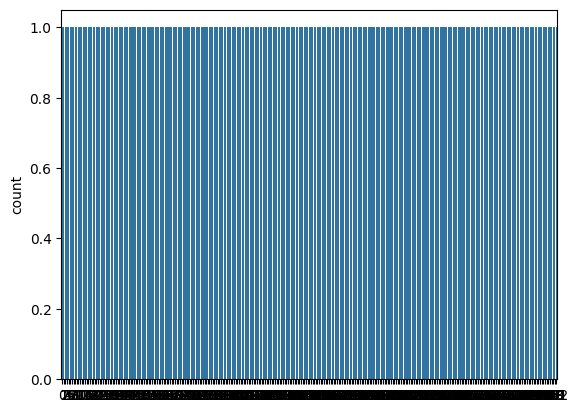

percentage of patients without heart problems:45.54
percentage of patients with heart problems:54.46


In [97]:
y = dataset["target"]
sns.countplot(y)
plt.show()
target_temp = dataset.target.value_counts()
print("percentage of patients without heart problems:"+str(round(target_temp[0]*100/303,2)))
print("percentage of patients with heart problems:"+str(round(target_temp[1]*100/303,2)))

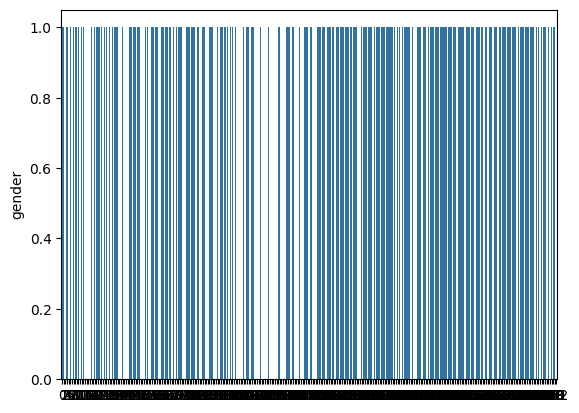

In [98]:
sns.barplot(dataset["gender"])
plt.show()

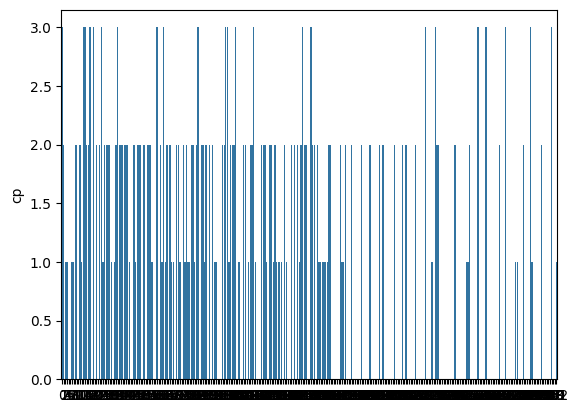

In [99]:
sns.barplot(dataset["cp"])
plt.show()

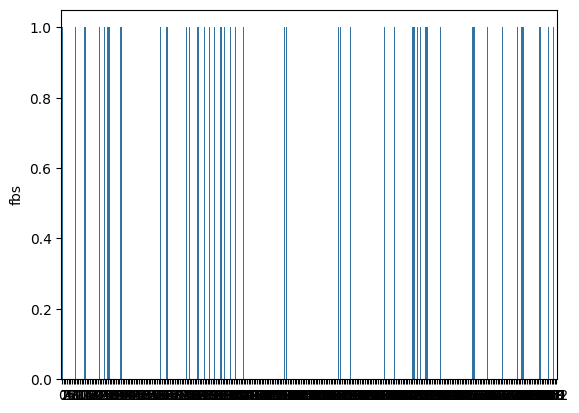

In [100]:
sns.barplot(dataset["fbs"])
plt.show()

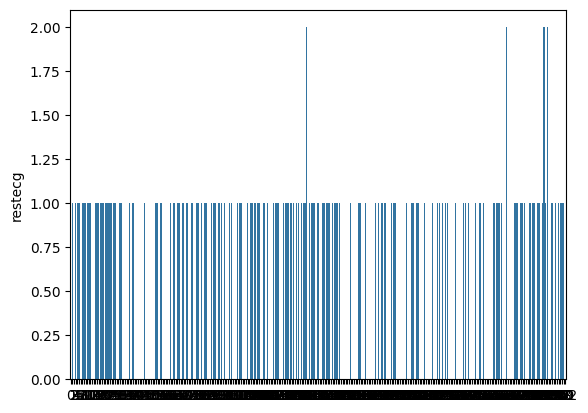

In [101]:
sns.barplot(dataset["restecg"])
plt.show()

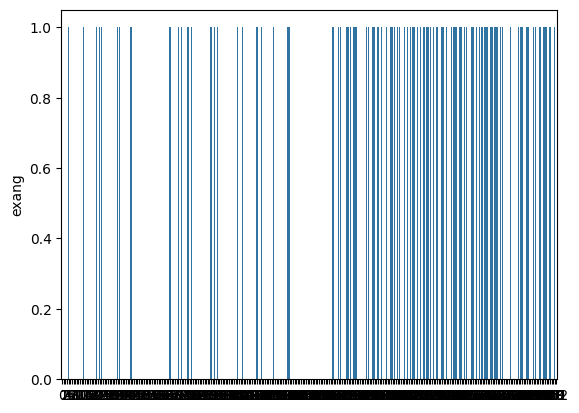

In [102]:
sns.barplot(dataset["exang"])
plt.show()

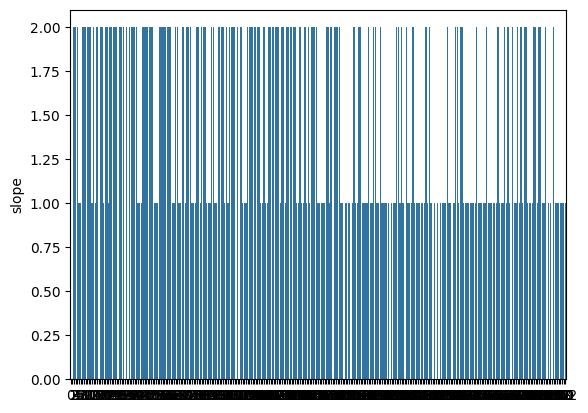

In [103]:
sns.barplot(dataset["slope"])
plt.show()

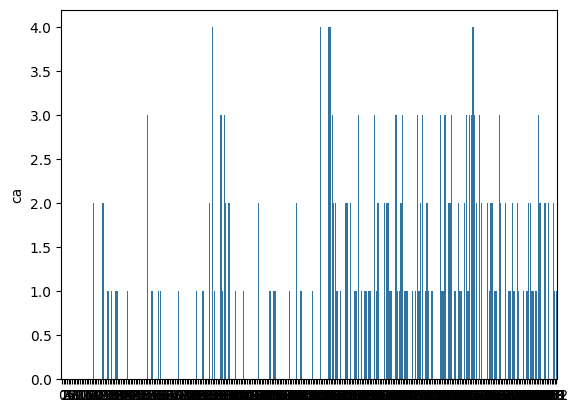

In [104]:
sns.barplot(dataset["ca"])
plt.show()

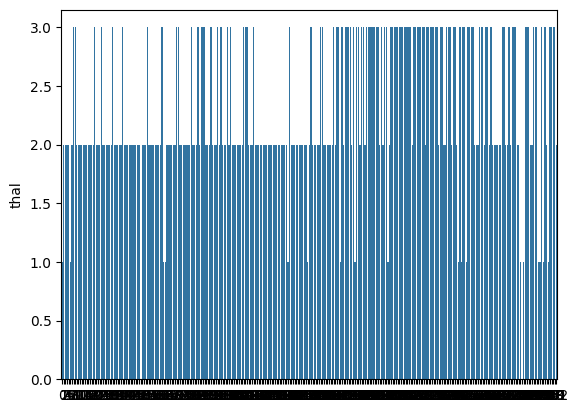

In [105]:
sns.barplot(dataset["thal"])
plt.show()

**Example 2**

*train test split*

In [106]:
from sklearn.model_selection import train_test_split
predictors = dataset.drop("target",axis =1)
target = dataset["target"]


In [107]:
X_train, X_test, Y_train, Y_test = train_test_split(predictors, target, test_size = 0.20, random_state = 0)
X_train.shape
X_test.shape
Y_train.shape
Y_test.shape

(61,)

**Example 3**

*KNN Implementation*

In [108]:
from numpy import *
import operator

# Fixed parameters: added 'labels' and removed the .shape[0] logic from the signature
def classify0(inX, dataset, labels, k):
    dataSetSize = dataset.shape[0]
    
    # 1. Calculate Euclidean Distance
    diffMat = tile(inX, (dataSetSize, 1)) - dataset
    sqdiffMat = diffMat ** 2
    sqDistances = sqdiffMat.sum(axis=1)
    distances = sqDistances**0.5
    
    # 2. Sort distances in ascending order
    sortedDistIndices = distances.argsort()
    
    # 3. Voting for the top k neighbors
    classCount = {}
    for i in range(k):
        voteIlabel = labels[sortedDistIndices[i]]
        classCount[voteIlabel] = classCount.get(voteIlabel, 0) + 1

    # 4. Sort the dictionary by value (vote count) and return the winner
    sortedClassCount = sorted(classCount.items(), 
                              key=operator.itemgetter(1), reverse=True)
    return sortedClassCount[0][0]

# Example call (assuming X_test, X_train, and Y_train are numpy arrays)
# print("predicted value is ", classify0(X_test[0], X_train, Y_train, 3))

**Example 4**

In [109]:
# 1. Scale the features (Important for kNN!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train KNN classifier with 5 neighbours
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, Y_train)

# 3. Predict using the scaled test data
Y_pred = knn.predict(X_test_scaled)

# 4. Evaluate
print("Accuracy of the model is:", metrics.accuracy_score(Y_test, Y_pred))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

Accuracy of the model is: 0.819672131147541
Confusion Matrix:
 [[21  6]
 [ 5 29]]


In [110]:
# finding all the performance metrics
from sklearn.metrics import classification_report


print("Classification Report:\n", classification_report(Y_test, Y_pred))
    

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.78      0.79        27
           1       0.83      0.85      0.84        34

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



In [111]:
# changing the value of k to 3,6,8 and 9

from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier


knn1 = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
knn1.fit(X_train_scaled, Y_train)
Y_pred = knn1.predict(X_test_scaled)
print("Accuracy of the model is:", metrics.accuracy_score(Y_test, Y_pred))

knn2 = KNeighborsClassifier(n_neighbors=6, n_jobs=-1)
knn2.fit(X_train_scaled, Y_train)
Y_pred = knn2.predict(X_test_scaled)
print("Accuracy of the model is:", metrics.accuracy_score(Y_test, Y_pred))

knn3 = KNeighborsClassifier(n_neighbors=8, n_jobs=-1)
knn3.fit(X_train_scaled, Y_train)
Y_pred = knn3.predict(X_test_scaled)
print("Accuracy of the model is:", metrics.accuracy_score(Y_test, Y_pred))

knn4 = KNeighborsClassifier(n_neighbors=9, n_jobs=-1)
knn4.fit(X_train_scaled, Y_train)
Y_pred = knn4.predict(X_test_scaled)
print("Accuracy of the model is:", metrics.accuracy_score(Y_test, Y_pred))

# finding performance metrics for all ks
for k in [3, 6, 8, 9]:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_scaled, Y_train)
    Y_pred = knn.predict(X_test_scaled)
    print(f"Classification Report for k={k}:\n", classification_report(Y_test, Y_pred))

Accuracy of the model is: 0.8360655737704918
Accuracy of the model is: 0.8360655737704918
Accuracy of the model is: 0.8524590163934426
Accuracy of the model is: 0.8524590163934426
Classification Report for k=3:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81        27
           1       0.85      0.85      0.85        34

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61

Classification Report for k=6:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81        27
           1       0.85      0.85      0.85        34

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61

Classification Report for k=8:
               precision    recall  f1-score   support

           0   

In [112]:
# Test the kNN algorithm with Euclidean and Manhattan distance metrics on heart dataset. Study the impact on performance metrics.

knn_euclidean = KNeighborsClassifier(n_neighbors=5, metric='euclidean', n_jobs=-1)
knn_euclidean.fit(X_train_scaled, Y_train)
Y_pred_euclidean = knn_euclidean.predict(X_test_scaled)
print("Accuracy with Euclidean distance:", metrics.accuracy_score(Y_test, Y_pred_euclidean))

knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan', n_jobs=-1)
knn_manhattan.fit(X_train_scaled, Y_train)
Y_pred_manhattan = knn_manhattan.predict(X_test_scaled)
print("Accuracy with Manhattan distance:", metrics.accuracy_score(Y_test, Y_pred_manhattan))
# finding all the performance metrics for both distance metrics
print("Classification Report for Euclidean distance:\n", classification_report(Y_test, Y_pred_euclidean))
print("Classification Report for Manhattan distance:\n", classification_report(Y_test, Y_pred_manhattan))

Accuracy with Euclidean distance: 0.819672131147541
Accuracy with Manhattan distance: 0.8360655737704918
Classification Report for Euclidean distance:
               precision    recall  f1-score   support

           0       0.81      0.78      0.79        27
           1       0.83      0.85      0.84        34

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

Classification Report for Manhattan distance:
               precision    recall  f1-score   support

           0       0.87      0.74      0.80        27
           1       0.82      0.91      0.86        34

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.83        61



In [118]:
dataset2 = pd.read_csv("spambase.csv")

In [119]:
# Assuming 'spam' is the last column in your CSV
X = dataset2.iloc[:, :-1].values  # All columns except the last
Y = dataset2.iloc[:, -1].values   # Just the last column (labels)

# Then split (you'll need this import if not already there)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [120]:
from numpy import *
import operator

# Fixed parameters: added 'labels' and removed the .shape[0] logic from the signature
def classify0(inX, dataset2, labels, k):
    dataSetSize = dataset2.shape[0]
    
    # 1. Calculate Euclidean Distance
    diffMat = tile(inX, (dataSetSize, 1)) - dataset2
    sqdiffMat = diffMat ** 2
    sqDistances = sqdiffMat.sum(axis=1)
    distances = sqDistances**0.5
    
    # 2. Sort distances in ascending order
    sortedDistIndices = distances.argsort()
    
    # 3. Voting for the top k neighbors
    classCount = {}
    for i in range(k):
        voteIlabel = labels[sortedDistIndices[i]]
        classCount[voteIlabel] = classCount.get(voteIlabel, 0) + 1

    # 4. Sort the dictionary by value (vote count) and return the winner
    sortedClassCount = sorted(classCount.items(), 
                              key=operator.itemgetter(1), reverse=True)
    return sortedClassCount[0][0]


In [121]:
# 1. Scale the features (Important for kNN!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train KNN classifier with 5 neighbours
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, Y_train)

# 3. Predict using the scaled test data
Y_pred = knn.predict(X_test_scaled)

# 4. Evaluate
print("Accuracy of the model is:", metrics.accuracy_score(Y_test, Y_pred))
print("Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

Accuracy of the model is: 0.8935939196525515
Confusion Matrix:
 [[494  37]
 [ 61 329]]


In [122]:
# spam base dataset performance metrics
print("Classification Report:\n", classification_report(Y_test, Y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91       531
           1       0.90      0.84      0.87       390

    accuracy                           0.89       921
   macro avg       0.89      0.89      0.89       921
weighted avg       0.89      0.89      0.89       921



In [123]:
# comparing the results of the two datasets
print("Accuracy on Heart Dataset:", metrics.accuracy_score(Y_test, Y_pred))
print("Accuracy on Spam Dataset:", metrics.accuracy_score(Y_test, Y_pred))

Accuracy on Heart Dataset: 0.8935939196525515
Accuracy on Spam Dataset: 0.8935939196525515
